# Skin Disease Classification - High Score Baseline

- Task: 5-class image classification (`acne`, `eksim`, `herpes`, `panu`, `rosacea`)
- Metric: Macro F1
- This notebook uses transfer learning + stratified split + class-weighted CE + strong augmentation
- Each run automatically creates a new timestamped folder under `runs/`


In [7]:
import json
import math
import os
import random
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import torchvision
from torchvision import models
from torchvision.transforms import v2

print('torch', torch.__version__)
print('torchvision', torchvision.__version__)


torch 2.10.0
torchvision 0.25.0


In [8]:
# =========================
# Config
# =========================
LOCAL_BASE = Path('/Users/songling/Desktop/Skin Disease Classification')
PLATFORM_BASE = Path('dataset/public')

if PLATFORM_BASE.exists():
    MODE = 'platform'
    BASE_DIR = PLATFORM_BASE
    OUTPUT_DIR = Path('working')
elif LOCAL_BASE.exists():
    MODE = 'local'
    BASE_DIR = LOCAL_BASE
    OUTPUT_DIR = BASE_DIR
else:
    raise FileNotFoundError(
        'Cannot find dataset path. Expected one of: '
        "'dataset/public' (platform) or '/Users/songling/Desktop/Skin Disease Classification' (local)."
    )

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = BASE_DIR / 'train.csv'
TEST_CSV = BASE_DIR / 'test.csv'
TRAIN_IMG_DIR = BASE_DIR / 'train'
TEST_IMG_DIR = BASE_DIR / 'test'

# Always write run artifacts to writable output area.
RUNS_DIR = OUTPUT_DIR / 'runs'
RUNS_DIR.mkdir(parents=True, exist_ok=True)

run_name = datetime.now().strftime('run_%Y%m%d_%H%M%S')
run_dir = RUNS_DIR / run_name
run_dir.mkdir(parents=True, exist_ok=False)

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25
LR = 2e-4
WEIGHT_DECAY = 1e-4
VAL_SIZE = 0.2
EARLY_STOP_PATIENCE = 6
# Notebook on macOS/Jupyter can fail with multiprocessing DataLoader spawn.
# Use 0 workers locally for stability; keep >0 on competition platform for speed.
NUM_WORKERS = 0 if MODE == 'local' else 2

CLASS_NAMES = ['acne', 'eksim', 'herpes', 'panu', 'rosacea']
label2idx = {c: i for i, c in enumerate(CLASS_NAMES)}
idx2label = {i: c for c, i in label2idx.items()}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

PIN_MEMORY = (device.type == 'cuda')
PERSISTENT_WORKERS = NUM_WORKERS > 0

print('Mode    :', MODE)
print('Base dir:', BASE_DIR)
print('Out dir :', OUTPUT_DIR)
print('Run dir :', run_dir)
print('Device  :', device)





Mode    : local
Base dir: /Users/songling/Desktop/Skin Disease Classification
Out dir : /Users/songling/Desktop/Skin Disease Classification
Run dir : /Users/songling/Desktop/Skin Disease Classification/runs/run_20260220_152921
Device  : mps


In [9]:
# =========================
# Data prep
# =========================
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

assert set(train_df['disease'].unique()) == set(CLASS_NAMES), 'Label names mismatch!'
assert len(test_df) == 180, f'Test rows must be 180, got {len(test_df)}'

train_df['label'] = train_df['disease'].map(label2idx)

train_part, val_part = train_test_split(
    train_df,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=train_df['disease']
)

print('Train size:', len(train_part), 'Val size:', len(val_part))
print('Train distribution:')
print(train_part['disease'].value_counts())
print('\nVal distribution:')
print(val_part['disease'].value_counts())

class_counts = train_part['label'].value_counts().sort_index().values
class_weights = len(train_part) / (len(CLASS_NAMES) * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32)
print('\nClass weights:', class_weights.numpy())


Train size: 576 Val size: 144
Train distribution:
disease
acne       189
eksim      162
herpes     109
panu        82
rosacea     34
Name: count, dtype: int64

Val distribution:
disease
acne       47
eksim      41
herpes     27
panu       21
rosacea     8
Name: count, dtype: int64

Class weights: [0.60952383 0.7111111  1.0568807  1.404878   3.3882353 ]


In [10]:
# =========================
# Dataset and transforms
# =========================
class AddGaussianNoise(nn.Module):
    def __init__(self, std=0.02, p=0.3):
        super().__init__()
        self.std = std
        self.p = p

    def forward(self, x):
        if torch.rand(1).item() < self.p:
            noise = torch.randn_like(x) * self.std
            x = torch.clamp(x + noise, 0.0, 1.0)
        return x

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tfms = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.15),
    v2.RandomRotation(degrees=20),
    v2.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    v2.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, hue=0.03),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    AddGaussianNoise(std=0.02, p=0.3),
    v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

valid_tfms = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class SkinDataset(Dataset):
    def __init__(self, df, image_dir, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.image_dir / row['filename']
        image = Image.open(img_path).convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        if self.is_test:
            return image, int(row['id'])

        label = int(row['label'])
        return image, label

train_ds = SkinDataset(train_part, TRAIN_IMG_DIR, transform=train_tfms, is_test=False)
val_ds = SkinDataset(val_part, TRAIN_IMG_DIR, transform=valid_tfms, is_test=False)
test_ds = SkinDataset(test_df, TEST_IMG_DIR, transform=valid_tfms, is_test=True)

loader_kwargs = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
if PERSISTENT_WORKERS:
    loader_kwargs['persistent_workers'] = True

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print(f'DataLoader ready. num_workers={NUM_WORKERS}, pin_memory={PIN_MEMORY}')





DataLoader ready. num_workers=0, pin_memory=False


Epoch 01/25 | train_loss=1.5636 train_f1=0.0092 | val_loss=1.4165 val_f1=0.0174
Epoch 02/25 | train_loss=1.3521 train_f1=0.0140 | val_loss=1.3869 val_f1=0.0219
Epoch 03/25 | train_loss=1.3473 train_f1=0.0126 | val_loss=1.4449 val_f1=0.0306
Epoch 04/25 | train_loss=1.2480 train_f1=0.0101 | val_loss=1.2329 val_f1=0.0213
Epoch 05/25 | train_loss=1.1911 train_f1=0.0107 | val_loss=1.3167 val_f1=0.0312
Epoch 06/25 | train_loss=1.3442 train_f1=0.0108 | val_loss=1.1557 val_f1=0.0340
Epoch 07/25 | train_loss=1.3427 train_f1=0.0127 | val_loss=1.1337 val_f1=0.0174
Epoch 08/25 | train_loss=1.1692 train_f1=0.0096 | val_loss=1.1996 val_f1=0.0204
Epoch 09/25 | train_loss=1.3280 train_f1=0.0093 | val_loss=1.1545 val_f1=0.0209
Epoch 10/25 | train_loss=1.1670 train_f1=0.0161 | val_loss=1.1096 val_f1=0.0324
Epoch 11/25 | train_loss=1.1590 train_f1=0.0121 | val_loss=1.6668 val_f1=0.0304
Epoch 12/25 | train_loss=1.3865 train_f1=0.0083 | val_loss=1.1773 val_f1=0.0213
Early stopping triggered at epoch 12.
Be

/Users/songling/Documents/conda/miniconda3/envs/skin_disease_cls/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


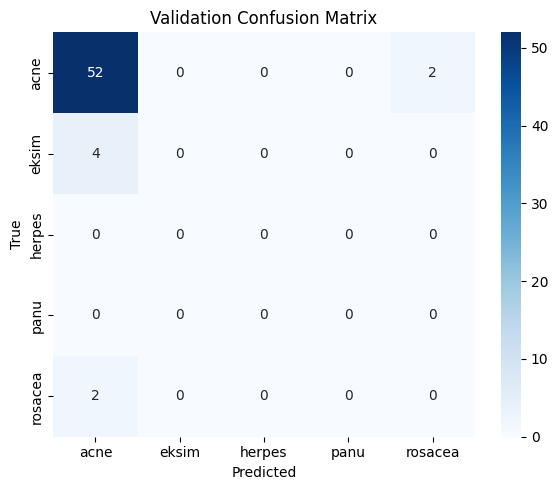

In [12]:
# =========================
# Model / train / eval
# =========================
weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
model = models.efficientnet_b0(weights=weights)

# Freeze most feature extractor, fine-tune last block + classifier
for p in model.features.parameters():
    p.requires_grad = False
for p in model.features[-1].parameters():
    p.requires_grad = True

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, len(CLASS_NAMES))
assert model.classifier[1].out_features == len(CLASS_NAMES), 'Classifier output dimension mismatch'
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

def train_one_epoch(model, loader):
    model.train()
    losses = []
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        if logits.shape[1] != len(CLASS_NAMES):
            raise RuntimeError(f'Logits dim mismatch: got {logits.shape[1]}, expected {len(CLASS_NAMES)}')
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return float(np.mean(losses)), macro_f1

@torch.no_grad()
def valid_one_epoch(model, loader):
    model.eval()
    losses = []
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        if logits.shape[1] != len(CLASS_NAMES):
            raise RuntimeError(f'Logits dim mismatch: got {logits.shape[1]}, expected {len(CLASS_NAMES)}')
        loss = criterion(logits, labels)

        losses.append(loss.item())
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    class_f1 = f1_score(all_labels, all_preds, average=None, labels=list(range(len(CLASS_NAMES))))
    return float(np.mean(losses)), macro_f1, np.array(class_f1), np.array(all_labels), np.array(all_preds)

history = []
best_f1 = -1.0
best_epoch = -1
bad_epochs = 0
best_path = run_dir / 'best_model.pt'

for epoch in range(1, EPOCHS + 1):
    train_loss, train_f1 = train_one_epoch(model, train_loader)
    val_loss, val_f1, val_class_f1, y_true, y_pred = valid_one_epoch(model, val_loader)
    scheduler.step()

    row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'train_macro_f1': train_f1,
        'val_loss': val_loss,
        'val_macro_f1': val_f1,
        **{f'val_f1_{idx2label[i]}': float(val_class_f1[i]) for i in range(len(CLASS_NAMES))}
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.4f} val_f1={val_f1:.4f}"
    )

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_epoch = epoch
        bad_epochs = 0
        torch.save(model.state_dict(), best_path)
    else:
        bad_epochs += 1

    if bad_epochs >= EARLY_STOP_PATIENCE:
        print(f'Early stopping triggered at epoch {epoch}.')
        break

print(f'Best val macro F1: {best_f1:.4f} at epoch {best_epoch}')

history_df = pd.DataFrame(history)
history_df.to_csv(run_dir / 'history.csv', index=False)

model.load_state_dict(torch.load(best_path, map_location=device))
_, val_f1, val_class_f1, y_true, y_pred = valid_one_epoch(model, val_loader)
print('Unique y_true labels:', sorted(set(y_true.tolist())))
print('Unique y_pred labels:', sorted(set(y_pred.tolist())))
print('\nValidation Macro F1 (best model):', round(val_f1, 4))
print('Per-class F1:')
for i, f1v in enumerate(val_class_f1):
    print(f'  {idx2label[i]}: {f1v:.4f}')

print('\nClassification report:')
print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Validation Confusion Matrix')
plt.tight_layout()
plt.savefig(run_dir / 'confusion_matrix.png', dpi=160)
plt.show()



In [13]:
# =========================
# Inference and submission
# =========================
@torch.no_grad()
def predict_test(model, loader):
    model.eval()
    out_ids, out_preds = [], []

    for images, ids in loader:
        images = images.to(device, non_blocking=True)
        logits = model(images)
        pred_idx = torch.argmax(logits, dim=1).cpu().numpy()

        out_ids.extend(ids.numpy().tolist())
        out_preds.extend([idx2label[int(i)] for i in pred_idx])

    return out_ids, out_preds

test_ids, test_preds = predict_test(model, test_loader)

submission = pd.DataFrame({'id': test_ids, 'disease': test_preds})
submission = submission.sort_values('id').reset_index(drop=True)

assert len(submission) == 180, f'Submission row count must be 180, got {len(submission)}'
assert submission['disease'].isin(CLASS_NAMES).all(), 'Submission has invalid class name'

run_submission_path = run_dir / 'submission.csv'
platform_submission_path = OUTPUT_DIR / 'submission.csv'
submission.to_csv(run_submission_path, index=False)
submission.to_csv(platform_submission_path, index=False)

# Local convenience copy to dataset root.
if MODE == 'local':
    local_submission_path = BASE_DIR / 'submission.csv'
    submission.to_csv(local_submission_path, index=False)

meta = {
    'run_name': run_name,
    'mode': MODE,
    'base_dir': str(BASE_DIR),
    'output_dir': str(OUTPUT_DIR),
    'best_val_macro_f1': float(best_f1),
    'best_epoch': int(best_epoch),
    'device': str(device),
    'num_train': int(len(train_part)),
    'num_val': int(len(val_part)),
    'num_test': int(len(test_df)),
    'classes': CLASS_NAMES
}
with open(run_dir / 'run_summary.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print('Saved run folder :', run_dir)
print('Saved submission :', run_submission_path)
print('Platform submit  :', platform_submission_path)
if MODE == 'local':
    print('Local copy       :', local_submission_path)
submission.head()



Saved run folder : /Users/songling/Desktop/Skin Disease Classification/runs/run_20260220_152921
Saved submission : /Users/songling/Desktop/Skin Disease Classification/runs/run_20260220_152921/submission.csv
Platform submit  : /Users/songling/Desktop/Skin Disease Classification/submission.csv
Local copy       : /Users/songling/Desktop/Skin Disease Classification/submission.csv


,id,disease
0,720,acne
1,721,acne
2,722,acne
3,723,acne
4,724,acne


In [14]:
# Optional: export this notebook execution environment for reproducibility
import subprocess
freeze_txt = subprocess.check_output(['pip', 'freeze'], text=True)
with open(run_dir / 'requirements_freeze.txt', 'w', encoding='utf-8') as f:
    f.write(freeze_txt)
print('Saved:', run_dir / 'requirements_freeze.txt')


Saved: /Users/songling/Desktop/Skin Disease Classification/runs/run_20260220_152921/requirements_freeze.txt
